In [2]:
import numpy as np
import random
from functools import reduce
from itertools import chain, combinations, product, repeat
from scipy import linalg, sparse
import matplotlib.pyplot as plt
import os
from scipy.stats import unitary_group
import time 
from toqito.channels import partial_trace

In [3]:
# Gates:

Id2 = np.array([[1,0],[0,1]], dtype = 'complex128')
S_X = np.array([[0,1],[1,0]], dtype = 'complex128')
S_Y = np.array([[0,-1j],[1j,0]], dtype = 'complex128')
S_Z = np.array([[1,0],[0,-1]], dtype = 'complex128')
paulis = [Id2, S_X, S_Y, S_Z]/np.sqrt(2)
basis4by4=np.kron(paulis,paulis)


def inner(X,Y):
    if type(X)!=np.ndarray:
        X=X.toarray()
        Y=Y.toarray()
    prod=np.trace(X.T.conj()@Y)
    return prod
    
# uniform-U(4) matrices:
# checked that the eigenvalue distribution is uniform
def mkU(n):
    Un = (np.random.random([n,n]) + 1j* np.random.random([n,n]))/np.sqrt(2)
    q,r = linalg.qr(Un)
    #d = np.diag(r)
    #ph = d/abs(d)
    #q = q * ph * q   
    return q

""" TO DO
check the difference between this function and x=unitary_group.rvs(3)
and the Gaussian unitary ensemble
"""


def mkLiouvillian(rate, dt, ldbldOp): 
    # Not sure how to include an environment qutrit and maintain unitarity

    L1 = np.kron(np.sqrt(rate/2) *ldbldOp, np.eye(2))
    L2 = np.kron(np.eye(2), np.sqrt(rate/2) *ldbldOp)
    
    h = -1j * linalg.logm(unitary_group.rvs(4)) #- (np.kron(ldbldOp, np.eye(2)) + np.kron(np.eye(2), ldbldOp))
    
    H =  (np.kron(h.conj(), np.eye(4)) - np.kron(np.eye(4), h) )
    
    #print(np.allclose(H, H.T.conj()))
    lindblads = [L1,L2]
    
    G = np.zeros([len(L1)**2,len(L1)**2], dtype = 'complex128')
    for L in lindblads:
        G += np.kron(L.conj(), L) - 1/2 * np.kron(np.eye(len(L)), L.T.conj()@L) - 1/2 * np.kron(L.T@L.conj(), np.eye(len(L)))
        
    # print(np.allclose(G, G.T.conj()) )
    denseU=linalg.expm( (-1j*H + G) * dt)
    
    return denseU # to act on the vectorized density matrix of 2 qubits

def mkKrausOps(U): 
    X = np.reshape(np.transpose(np.reshape(U,[4]*int(np.log2(len(U)))),[0,2,1,3]),list(U.shape))
    [eigVals, eigVecs] = linalg.eigh(X)
    
    krausOps=[]
    
    for i in range(len(U)):
        if abs(eigVals[i])>1e-10:
            krausOps = krausOps + [ sparse.csr_matrix(np.sqrt(eigVals[i]) * np.reshape(eigVecs[:,i],[4,4]))]
            
    return krausOps


def decompKrausOps(krausOps):
    # for each kraus operator, there is a set of k_abs that
    # stores the inner product of each on-site kraus ops with the basis in a row
    
    k_abs=np.array([[] for i in range(16)],dtype='complex128').T
    for (k,op) in enumerate(krausOps):
        k_temp = np.zeros(len(basis4by4),dtype='complex128')
        for (i,b) in enumerate(basis4by4):
            k_temp[i] = inner(b, op)
        k_abs = np.vstack([k_abs,k_temp])
        
    return k_abs


In [4]:
# at layers where PBC is not needed
def mkGlobalKrausOps(layer, Nqubit, rate, dt, ldbldOp, debug=True):
    
    allKs = {}

    if np.mod(layer,2) == 0:    
        # position records the site with the non-trivial unitary
        
        positions = [i for i in range(0, Nqubit-1, 2)]
        
        for pos in positions:
            
            # one needs to make N/2 different random unitaries 
            krausOps = mkKrausOps(mkLiouvillian(rate, dt, ldbldOp=S_Z))
            allKs[pos] = []

            for i in range(len(krausOps)):
                U_chain = chain(repeat(np.eye(4), pos//2), [krausOps[i]], repeat(np.eye(4), Nqubit//2 - pos//2 - 1))
                allKs[pos] += [reduce(sparse.kron, U_chain)]

    else:
        positions = list(range(1,Nqubit,2))
        
        for pos in positions:  
            krausOps = mkKrausOps(mkLiouvillian(rate, dt, ldbldOp))
            allKs[pos] = []
            
            if pos < Nqubit-1:

                for i in range(len(krausOps)):
                    U_chain = chain([np.eye(2)], repeat(np.eye(4), pos//2), [krausOps[i]], repeat(np.eye(4), Nqubit//2 - pos//2 - 2), [np.eye(2)])
                    allKs[pos] += [reduce(sparse.kron, U_chain)]
                    
            else:
                # decomposition of Kraus is required with PBC
                
                k_abs = decompKrausOps(krausOps)
                
                for row in k_abs:

                    K_jk = sparse.csr_matrix(np.zeros([2**Nqubit,2**Nqubit], dtype='complex128') )

                    for (basisInd, whichPauli) in enumerate(row):  
                        U_chain = np.array([np.eye(2)] * Nqubit,dtype='complex128') 
                        U_chain[pos] = paulis[basisInd//4] 
                        U_chain[np.mod(pos+1,Nqubit)] = paulis[np.mod(basisInd,4)] 

                        K_jk +=  row[basisInd] * reduce(sparse.kron, chain(U_chain))

                    allKs[pos] = allKs[pos] + [K_jk]   

    return allKs

In [5]:
# employ the faster Kraus Unitary sum
def evolveKrausU(allKs, rho, debug = False):
    
    Nqubit = int(np.log2(len(rho.toarray())))
 
    newRho = rho
    for key in allKs.keys():
        rho = newRho
        newRho = sparse.csr_matrix(np.zeros([2**Nqubit,2**Nqubit]) )

        for mat in allKs[key]:
            newRho += mat @ rho @ mat.T.conj()   
            
            #if debug == True:
            #    print(np.trace(newRho.toarray()))
        
    return newRho


# make measurement  (something is wrong with this thing)
"""TO DO
what on earth is that error???? or in the entanglement entropy computation
"""
def mkS_zMsm(probMsm, rho , debug=False):
    
    sites = [n for n in range(Nqubit)]
    randomNumbers = np.random.uniform(0,1,Nqubit)
    msmSites = np.where(randomNumbers < probMsm)[0]

    if list(msmSites) !=[]:

        Projs = [
            (np.eye(2)+S_Z)/2, 
            (np.eye(2)+(-1)*S_Z)/2
        ]

        numMsSites=len(msmSites)
        #print(msmSites)
        
        # make one projection msm at a time:
        for (j,ms) in enumerate(msmSites):  
            proj_chain = [np.eye(2)] * Nqubit
            proj_chain[ms] = Projs[0]
            proj0p = reduce(sparse.kron, proj_chain)
            
            proj_chain = [np.eye(2)] * Nqubit
            proj_chain[ms] = Projs[1]
            proj1p = reduce(sparse.kron, proj_chain)

            # probability of having one of the outcomes
            prob = np.trace((proj0p @ rho @ proj0p.T.conj()).toarray())
            if np.random.random(1) < prob:
                testRho = (proj0p @ rho @ proj0p.T.conj())/prob
                
            else:
                testRho = (proj1p @ rho @ proj1p.T.conj())/(1-prob)

            ## check if the other prob is complementary
            #prob1 = np.trace((proj1p@rho@proj1p.T.conj()).toarray())
            #print(prob+prob1)
            if debug: 
                print(np.trace(testRho.toarray()))
                print(proj_chain)
                
            # One needs to keep track of the measurement!!!
            rho = testRho

    else:
        testRho = rho

    return testRho 


In [6]:
def ptrace_rho(operator, elements):    

    halflength = int(np.log2(operator.shape[0]))
    reorder = np.reshape(operator, (2,)*(2*halflength))
    rho = np.transpose(reorder, [n//2+halflength*(n%2) for n in range(0,halflength*2)])

    elems = set(elements)
    counter = 0
    indexarr = []
    for i in range(len(rho.shape)//2):
        if i in elems:
            indexarr += [counter,counter]
            counter += 1
        else:
            indexarr += [counter,counter+1]
            counter += 2
            
    operator= np.einsum(rho, indexarr)
    length = len(operator.shape)
    halflength = length//2
    reorder = np.transpose(operator,[2*n for n in range(0,halflength)]+[2*n+1 for n in range(0,halflength)])
    
    return np.reshape(reorder, (np.prod(operator.shape[::2]), np.prod(operator.shape[1::2])))


def calcS(densityM, partiesToTraceOut):
    Ntot=int(np.log2(densityM.shape[0]))
    
    redRho = ptrace_rho(densityM, partiesToTraceOut)
    
    #redRho = partial_trace(densityM, partiesToTraceOut, [2]* Ntot)
    eVals = np.linalg.eigvalsh(redRho)
    eVals = eVals[np.where(eVals>1e-12)]
    S = -sum(eVals*np.log2(eVals))
    return S

def calcPurity(densityM):
    purity = np.trace(densityM@densityM)
    return purity
    

In [7]:
import seaborn as sbn
sbn.set(context='paper', font_scale=0.8, color_codes=True, palette='deep',style='ticks',
        rc={'mathtext.fontset': 'cm', 'axes.linewidth': 1, 'figure.dpi':300, 'figure.figsize':(2,1.5)})

In [8]:
# Now check msm probabilities

qb={}
qb[0]=np.array([1,0],dtype='complex128')
qb[1]=np.array([0,1],dtype='complex128')

Nqubit = 2
# pure state start
state0 = (qb[0] + qb[1])/np.sqrt(2)
state0rho = np.outer(state0, state0)

N=1000
purities1000 = np.zeros(N)
Nqubit=2
r=0.001

rho = sparse.csr_matrix(reduce(sparse.kron, [state0rho]*Nqubit))
for s in range(N): 
    purities1000[s]=calcPurity(rho.toarray())

    # OK this the KrausOps can be computed outside of the loop, which gives one 2 sets of Kraus ops
    allKrausOps = mkGlobalKrausOps(layer=s, Nqubit=Nqubit, rate=r, dt=5, ldbldOp=S_Z, debug=False)
    # ok the trace is not 1

    # Then the based on which layer, the evolve Kraus pick one of the 2 sets
    rho = evolveKrausU(allKrausOps, rho, debug = False)


/Users/cathy/anaconda3/lib/python3.7/site-packages/ipykernel_launcher.py:19: ComplexWarning: Casting complex values to real discards the imaginary part


In [8]:
# Now check jump rates

qb={}
qb[0]=np.array([1,0],dtype='complex128')
qb[1]=np.array([0,1],dtype='complex128')

Nqubit = 8

# pure state start
state0 = (qb[0] + qb[1])/np.sqrt(2)
state0rho = np.outer(state0, state0)
rho = sparse.csr_matrix(reduce(sparse.kron, [state0rho]*Nqubit))

t_total = 300
probMsm = 0
dt=5
steps = int(t_total/dt)
rep = 20

rateList = np.logspace(-5,3,9)

ensembleS_r = {}
ensembleP_r = {}

for rate in rateList:
    
    ensembleS_r[rate] = np.zeros([rep,steps])
    ensembleP_r[rate] = np.zeros([rep,steps])

    startTime = time.time()
    
    for e in range(rep):
        rho = sparse.csr_matrix(reduce(sparse.kron, [state0rho]*Nqubit))
        SList = np.zeros(steps)
        PList = np.zeros(steps)

        for s in range(steps):
            
            allKrausOps = mkGlobalKrausOps(s, Nqubit, rate, dt, ldbldOp=S_Z, debug=False)
            rho = evolveKrausU(allKrausOps, rho, False)
            #rho = mkS_zMsm(probMsm, rho)

            SList[s] = calcS(rho.toarray(), partiesToTraceOut=list(range(0,Nqubit//2-1)))
            PList[s] = calcPurity(rho.toarray())

            ensembleS_r[rate][e,s] = SList[s]
            ensembleP_r[rate][e,s] = PList[s]


    print(time.time()-startTime)


/Users/cathy/anaconda3/lib/python3.7/site-packages/ipykernel_launcher.py:44: ComplexWarning: Casting complex values to real discards the imaginary part


880.7187979221344
899.2023601531982
897.0985081195831
909.9775259494781
887.3573410511017
830.3112852573395
26654.055810928345
941.3091878890991
966.4249842166901


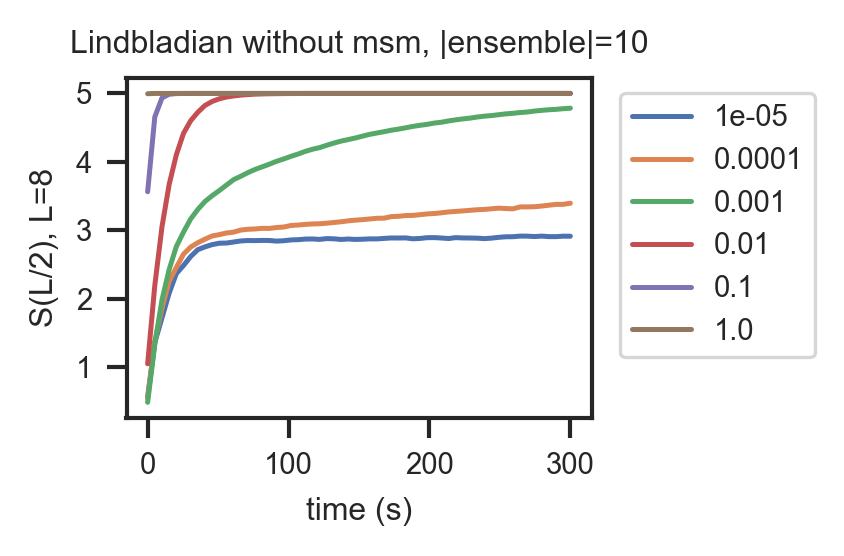

In [14]:
plt.figure()
# It seems that rate = 1, 10, 100 and 1000 all have the same behavior

rateList = np.logspace(-5,0,6)
duration = np.linspace(0,t_total,int(t_total/dt))

for (j,rate) in enumerate(rateList):
    plt.plot(duration, np.average(ensembleS_r[rate] ,axis=0) )
plt.xlabel('time (s)')
plt.ylabel('S(L/2), L=8')
plt.title('Lindbladian without msm, |ensemble|=10')
plt.legend(rateList,bbox_to_anchor= (1.03, 1) )




In [21]:
sbn.set(context='paper', font_scale=0.8, color_codes=True, palette='deep',style='ticks',
        rc={'mathtext.fontset': 'cm', 'axes.linewidth': 1, 'figure.dpi':300, 'figure.figsize':(2,1.5)})

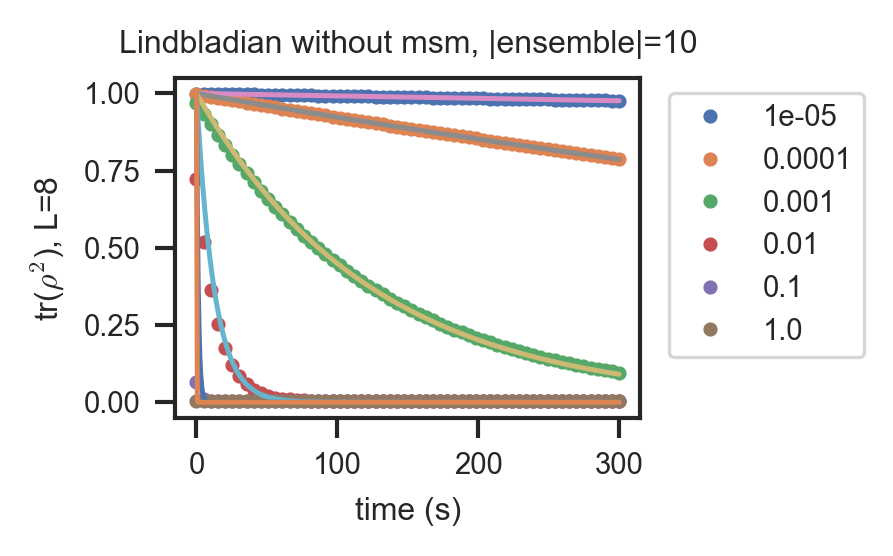

In [40]:
plt.figure()

for (j,rate) in enumerate(rateList):

    plt.plot(duration, np.average(ensembleP_r[rate] ,axis=0) ,'.')
    

plt.xlabel('time (s)')
plt.ylabel(r'tr($\rho^2$), L=8')
plt.title('Lindbladian without msm, |ensemble|=10')
plt.legend(rateList,bbox_to_anchor= (1.03, 1) )

for (j,rate) in enumerate(rateList):

    domain = np.linspace(0,t_total,500)
    plt.plot(domain, np.exp(-domain*rate*Nqubit) )



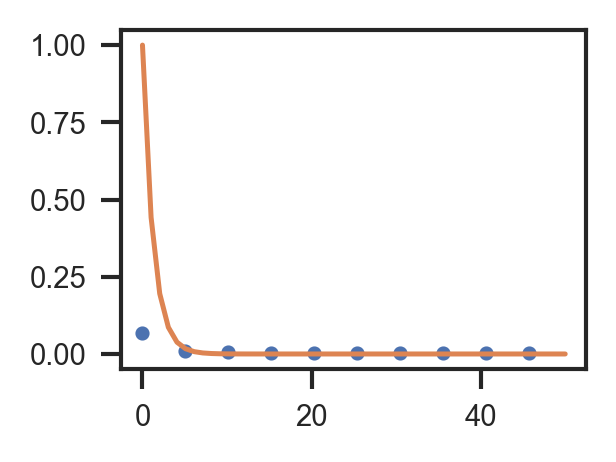

In [47]:
plt.plot(duration[:10], np.average(ensembleP_r[0.1] ,axis=0)[:10] ,'.')

domain = np.linspace(0,50)
plt.plot(domain, np.exp(-domain*0.1*Nqubit) )



In [163]:
def ptrace_rho(rho, elements):
    operator = rho
    halflength = int(np.log2(operator.shape[0]))
    reorder = np.reshape(operator, (2,)*(2*halflength))
    temp = np.transpose(reorder, [n//2+halflength*(n%2) for n in range(0,halflength*2)])
    #---------
    elems = set(elements)
    counter = 0
    indexarr = []
    for i in range(len(temp.shape)//2):
        if i in elems:
            indexarr += [counter,counter]
            counter += 1
        else:
            indexarr += [counter,counter+1]
            counter += 2
    operator = np.einsum(temp, indexarr)
    #---------------
    length = len(operator.shape)
    halflength = length//2
    
    if elements != []:
        operator = np.transpose(operator,[length-2,length-1]+list(range(0,length-2))) #cyclic permutation for toqito
    
    reorder = np.transpose(operator,[2*n for n in range(0,halflength)]+[2*n+1 for n in range(0,halflength)])
    return np.reshape(reorder, (np.prod(operator.shape[::2]), np.prod(operator.shape[1::2])))
 

In [165]:
ptrace_rho(rho.toarray(),[0,1,4,5,6]).round(3)

array([[ 0. +0.j,  0. +0.j,  0. +0.j,  0. +0.j,  0. +0.j,  0. +0.j,
         0. +0.j,  0. +0.j],
       [ 0. +0.j,  0. +0.j,  0. +0.j,  0. +0.j,  0. +0.j,  0. +0.j,
         0. +0.j,  0. +0.j],
       [ 0. +0.j,  0. +0.j,  0.5+0.j,  0. +0.j,  0. +0.j,  0. +0.j,
        -0. +0.j,  0. +0.j],
       [ 0. +0.j,  0. +0.j,  0. +0.j,  0. +0.j,  0. +0.j,  0. +0.j,
         0. +0.j,  0. +0.j],
       [ 0. +0.j,  0. +0.j,  0. +0.j,  0. +0.j,  0. +0.j,  0. +0.j,
         0. +0.j,  0. +0.j],
       [ 0. +0.j,  0. +0.j,  0. +0.j,  0. +0.j,  0. +0.j,  0. +0.j,
         0. +0.j,  0. +0.j],
       [ 0. +0.j,  0. +0.j, -0. -0.j,  0. +0.j,  0. +0.j,  0. +0.j,
         0.5-0.j,  0. +0.j],
       [ 0. +0.j,  0. +0.j,  0. +0.j,  0. +0.j,  0. +0.j,  0. +0.j,
         0. +0.j,  0. +0.j]])

In [154]:
partial_trace(rho.toarray(), [1,2,5,6,7], [2] * 8).round(3)

array([[ 0. +0.j,  0. +0.j,  0. +0.j,  0. +0.j,  0. +0.j,  0. +0.j,
         0. +0.j,  0. +0.j],
       [ 0. +0.j,  0. +0.j,  0. +0.j,  0. +0.j,  0. +0.j,  0. +0.j,
         0. +0.j,  0. +0.j],
       [ 0. +0.j,  0. +0.j,  0.5+0.j,  0. +0.j,  0. +0.j,  0. +0.j,
        -0. +0.j,  0. +0.j],
       [ 0. +0.j,  0. +0.j,  0. +0.j,  0. +0.j,  0. +0.j,  0. +0.j,
         0. +0.j,  0. +0.j],
       [ 0. +0.j,  0. +0.j,  0. +0.j,  0. +0.j,  0. +0.j,  0. +0.j,
         0. +0.j,  0. +0.j],
       [ 0. +0.j,  0. +0.j,  0. +0.j,  0. +0.j,  0. +0.j,  0. +0.j,
         0. +0.j,  0. +0.j],
       [ 0. +0.j,  0. +0.j, -0. -0.j,  0. +0.j,  0. +0.j,  0. +0.j,
         0.5-0.j,  0. +0.j],
       [ 0. +0.j,  0. +0.j,  0. +0.j,  0. +0.j,  0. +0.j,  0. +0.j,
         0. +0.j,  0. +0.j]])

In [98]:
partial_trace(np.reshape(np.arange(2**16),(2**8,2**8)),[1,2,3,4,5], [2] * 8).round(2)

array([[1019776, 1019840, 1019904, 1019968, 1019808, 1019872, 1019936,
        1020000],
       [1036160, 1036224, 1036288, 1036352, 1036192, 1036256, 1036320,
        1036384],
       [1052544, 1052608, 1052672, 1052736, 1052576, 1052640, 1052704,
        1052768],
       [1068928, 1068992, 1069056, 1069120, 1068960, 1069024, 1069088,
        1069152],
       [1027968, 1028032, 1028096, 1028160, 1028000, 1028064, 1028128,
        1028192],
       [1044352, 1044416, 1044480, 1044544, 1044384, 1044448, 1044512,
        1044576],
       [1060736, 1060800, 1060864, 1060928, 1060768, 1060832, 1060896,
        1060960],
       [1077120, 1077184, 1077248, 1077312, 1077152, 1077216, 1077280,
        1077344]])

In [ ]:
X = np.reshape(np.transpose(np.reshape(U,[4]*int(np.log2(len(U)))),[0,2,1,3]),list(U.shape))


In [120]:
def partialTrace(X, elements):
    N = len(X)
    tensorX = np.reshape(X,N*[2],'F') 
    output = np.tensordot(tensorX,tensorX,elements)
    
    return output

In [124]:
X=a
N = len(X)
elements = [1,2]
tensorX = np.reshape(X,N*[2],'F') 
output = np.tensordot(tensorX,tensorX)

In [126]:
tensorX

array([[[[ 0,  2],
         [ 1,  3]],

        [[ 8, 10],
         [ 9, 11]]],


       [[[ 4,  6],
         [ 5,  7]],

        [[12, 14],
         [13, 15]]]])

In [125]:
output

array([[[[ 56,  68],
         [ 62,  74]],

        [[248, 324],
         [286, 362]]],


       [[[152, 196],
         [174, 218]],

        [[344, 452],
         [398, 506]]]])

In [130]:
a = np.arange(16).reshape((4,4))
print(a)
print(np.trace(a,0))

ap = np.reshape(a,(2,2,2,2),'F')
print(ap)
print(sum(ap,2))


[[ 0  1  2  3]
 [ 4  5  6  7]
 [ 8  9 10 11]
 [12 13 14 15]]
30
[[[[ 0  2]
   [ 1  3]]

  [[ 8 10]
   [ 9 11]]]


 [[[ 4  6]
   [ 5  7]]

  [[12 14]
   [13 15]]]]
[[[ 6 10]
  [ 8 12]]

 [[22 26]
  [24 28]]]


In [160]:
a

array([[1, 0, 0, 0],
       [0, 0, 0, 0],
       [0, 0, 1, 0],
       [0, 0, 0, 0]])

In [164]:
ptrace_rho(a,[])

array([[1, 0, 0, 0],
       [0, 0, 0, 0],
       [0, 0, 1, 0],
       [0, 0, 0, 0]])

In [149]:
a = np.array([[1,0,0,0],[0,0,0,0],[0,0,1,0],[0,0,0,0]])
print('a=',a)

ap = np.reshape(a,(2,2,2,2),'F')
print('ap=', ap)
print('tensorDot=', np.tensordot(ap,[0,0]))
print('ptrace=',np.sum(ap,2))


a= [[1 0 0 0]
 [0 0 0 0]
 [0 0 1 0]
 [0 0 0 0]]
ap= [[[[1 0]
   [0 0]]

  [[0 1]
   [0 0]]]


 [[[0 0]
   [0 0]]

  [[0 0]
   [0 0]]]]
tensorDot= 2
ptrace= [[[1 0]
  [0 1]]

 [[0 0]
  [0 0]]]


In [166]:
a = np.arange(24).reshape((2,2,2,3))
print(a)
np.sum(a,1)

[[[[ 0  1  2]
   [ 3  4  5]]

  [[ 6  7  8]
   [ 9 10 11]]]


 [[[12 13 14]
   [15 16 17]]

  [[18 19 20]
   [21 22 23]]]]


array([[[ 6,  8, 10],
        [12, 14, 16]],

       [[30, 32, 34],
        [36, 38, 40]]])